In [1]:
#   VELDHUIZEN BENCHMARK
#   Contains 8 Objective Functions (OF) and 3 Constraints (CO). 
#   Decision 2 Decision Variables (DV), Real in the range (-4, +4) 
# 
#   Benchmark appears in [1]. It is attributed to a benchmark which 
#   appears in [2], however in that article there is no such problem 
#   formulation with 8 objectives (criteria). 
#   The correct reference is [3], same authors, same year but other venue. 
#
#   Formulation is implemented in python based on a previous verison of MATLAB
#   Makes use of PYMOO framework [4] for the MOO solution
#   
# 
# References:
# [1] Mehmet Unal and Gordon P. Warn and Timothy W. Simpson (2016)
#     Quantifying tradeoffs to reduce the dimensionality of complex design optimization problems 
#     and expedite trade space exploration.
#     Struct Multidisc Optim 54:233–248. doi 10.1007/s00158-015-1389-7
#
# [2] Chiu P-W, Bloebaum, CL (2008a) 
#     Hyper-radial visualization (HRV) with weighted preferences for multi-objective decision making. 
#     12th AIAA/ISSMO Multidisciplinary Analysis and Optimization Conference.
#     Victoria, British Columbia, Canada, AIAA, AIAA-2008-5986
#
# [3] Chiu P-W, Bloebaum, CL (2008b) 
#     Hyper-radial visualization (HRV) for Decision-making in MOO. 
#     46th AIAA Aerospace Sciences Meeting and Exhibit
#     7 - 10 January 2008, Reno, Nevada
#
# [4] J. Blank and K. Deb, (2020) 
#     pymoo: Multi-Objective Optimization in Python.
#     IEEE Access, 8(2020)89497-89509, 
#     doi: 10.1109/ACCESS.2020.2990567
#
#
# Developed by: Mario Castro-Gama, ir MSc PhD
#               Specialist Infrastructure at VITENS N.V.
# Last update: 2026-01-07, implemented
#              2026-01-14, added references

In [2]:
import time 
import numpy as np
from pymoo.core.problem import ElementwiseProblem

In [3]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

In [4]:
from pymoo.termination import get_termination

In [5]:
from pymoo.optimize import minimize

In [6]:
import matplotlib.pyplot as plt

In [7]:
class Veldhuizen(ElementwiseProblem):
    '''
     VELDHUIZEN BENCHMARK
      Contains 8 Objective Functions (OF) and 3 Constraints (CO). 
      Decision 2 Decision Variables (DV), Real in the range (-4, +4) 
     
      Benchmark appears in [1]. It is attributed to a benchmark which 
      appears in [2], however in that article there is no such problem 
      formulation with 8 objectives (criteria). 
      The correct reference is [3], same authors, same year but other venue. 
    
      Formulation is implemented in python based on a previous verison of MATLAB
      Makes use of PYMOO framework [4] for the MOO solution
      
    
    References:
    [1] Mehmet Unal and Gordon P. Warn and Timothy W. Simpson (2016)
        Quantifying tradeoffs to reduce the dimensionality of complex design optimization problems 
        and expedite trade space exploration.
        Struct Multidisc Optim 54:233–248. doi 10.1007/s00158-015-1389-7
    
    [2] Chiu P-W, Bloebaum, CL (2008a) 
        Hyper-radial visualization (HRV) with weighted preferences for multi-objective decision making. 
        12th AIAA/ISSMO Multidisciplinary Analysis and Optimization Conference.
        Victoria, British Columbia, Canada, AIAA, AIAA-2008-5986
    
    [3] Chiu P-W, Bloebaum, CL (2008b) 
        Hyper-radial visualization (HRV) for Decision-making in MOO. 
        46th AIAA Aerospace Sciences Meeting and Exhibit
        7 - 10 January 2008, Reno, Nevada
    
    [4] J. Blank and K. Deb, (2020) 
        pymoo: Multi-Objective Optimization in Python.
        IEEE Access, 8(2020)89497-89509, 
        doi: 10.1109/ACCESS.2020.2990567
        
    
    Developed by: Mario Castro-Gama, ir MSc PhD
                  sr Specialist Infrastructure at VITENS N.V.
    Last update: 2026-01-07, implemented
                 2026-01-14, added references
    
    '''
    def __init__(self):
        super().__init__(n_var=2,
                         n_obj=8,
                         n_ieq_constr=3,
                         xl=np.array([-4,-4]),
                         xu=np.array([+4,+4]))

    def _evaluate(self, x, out, *args, **kwargs):
        
        f1 = 0.5*(x[0]-2)*(x[0]-2) -  0.0769230769230769*(x[1]+1)*(x[1]+1) +3
        f2 = 0.00571428571428571*(x[0]+x[1]-3)*(x[0]+x[1]-3) + 0.0588235294117647*(2*x[1]-x[0])*(2*x[1]-x[0]) - 13
        f3 = 0.1250*(3*x[0]-2*x[1]+4)*(3*x[0]-2*x[1]+4) + 0.037037037037037*(x[0]-x[1]+1)*(x[0]-x[1]+1)+15
        f4 = 0.0294117647058824*(3*x[0]+x[1]+9)*(3*x[0]+x[1]+9) + 0.0666666666666667*(x[0]+1)*(x[0]+1) + 29
        f5 = 0.0454545454545455*(4*x[0]-x[1]-4)*(4*x[0]-x[1]-4) - 0.2*(x[1]-1)*(x[1]-1) - 17
        f6 = 0.1250*(x[1] + 14)*(x[1] + 14) +0.1*(x[0]+x[1])*(x[0]+x[1]) + 64
        # f(7) first term has power 3 and second power 1
        f7 = 0.00100502512562814*(17-x[0]-x[1])*(17-x[0]-x[1])*(17-x[0]-x[1]) + 0.0153846153846154*(8*x[1]-5*x[0])
        # f(8) first term has power 1 and second power 3
        f8 = 0.2*(7+2*x[0]+5*x[1]) +0.00425531914893617*(x[1]-3*x[0])*(x[1]-3*x[0])*(x[1]-3*x[0])
        
        # constraints are always given as gi <= 0
        g1 = +4.0*x[0] + 1.0*x[1] - 4.0 #<=0
        g2 = -1.0*x[0] + 0.0*x[1] - 1.0 #<=0
        g3 = +1.0*x[0] - 1.0*x[1] - 2.0 #<=0
    
        out['F'] = [f1, f2, f3, f4, f5, f6, f7, f8]
        out['G'] = [g1, g2, g3]


problem = Veldhuizen()

In [8]:
algorithm = NSGA2(
    pop_size     = 500,
    n_offsprings = 500,
    sampling     = FloatRandomSampling(),
    crossover    = SBX(prob=0.9, eta=15),
    mutation     = PM(eta=20),
    eliminate_duplicates = True
)

In [9]:
termination = get_termination('n_gen', 1000)

In [10]:
res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=False)

In [11]:
print('TOC optimization : '+str(round(res.exec_time,2))+' seconds')

TOC optimization : 106.94 seconds


In [12]:
X, F, G = res.opt.get('X', 'F', 'G')
print(X.shape, F.shape, G.shape)

(500, 2) (500, 8) (500, 3)


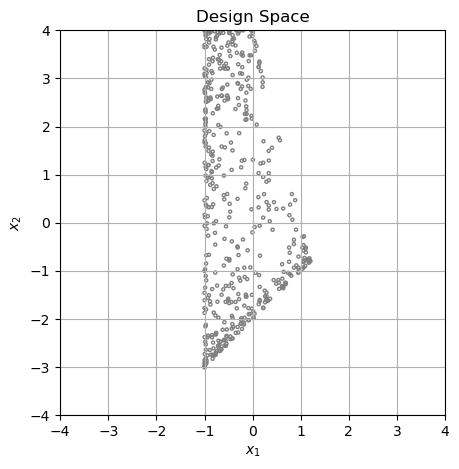

In [13]:
# plot results Decision Space
xl, xu = problem.bounds()
fig, axs = plt.subplots(figsize=(5,5), nrows=1, ncols=1)
axs.scatter(X[:, 0], X[:, 1], s=5, facecolors='none', edgecolors='gray')
axs.set_xlim(xl[0], xu[0])
plt.ylim(xl[1], xu[1])
axs.set_aspect('equal', 'box')
axs.set_title('Design Space')
axs.set_xlabel(r'$x_1$')
axs.set_ylabel(r'$x_2$')
plt.grid(which='both')
plt.show()

In [14]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

In [15]:
pf_idx = NonDominatedSorting().do(F, only_non_dominated_front=True)
print(len(pf_idx))
X_pareto = X[pf_idx]
F_pareto = F[pf_idx]
len(X_pareto), len(F_pareto)

500


(500, 500)

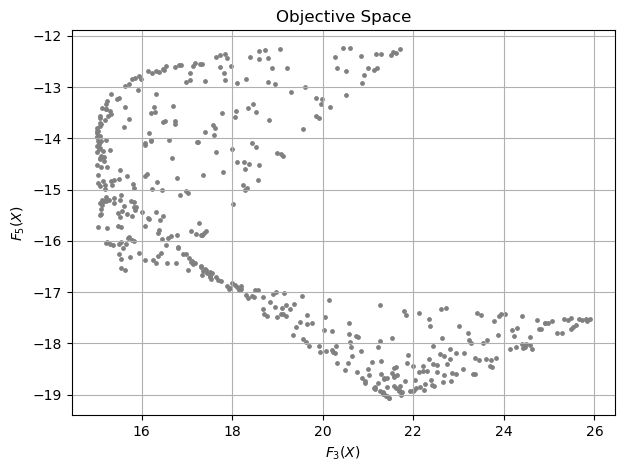

In [16]:
# plot results Objective Space
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 2], F[:, 4], s=6, facecolors='gray', edgecolors='gray')
plt.title("Objective Space")
plt.xlabel(r'$F_3(X)$')
plt.ylabel(r'$F_5(X)$')
plt.grid(which='both')
plt.show()

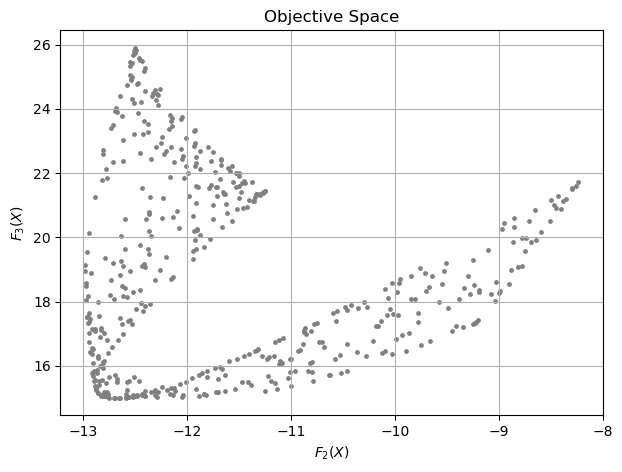

In [17]:
# plot results Objective Space
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 1], F[:, 2], s=6, facecolors='gray', edgecolors='gray')
plt.title("Objective Space")
plt.xlabel(r'$F_2(X)$')
plt.ylabel(r'$F_3(X)$')
plt.grid(which='both')
plt.show()

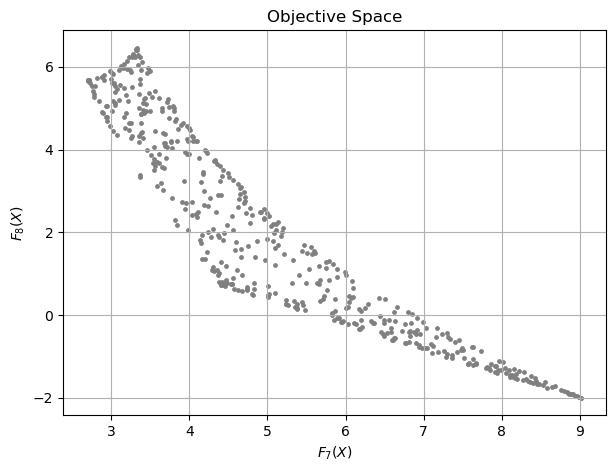

In [18]:
# plot results Objective Space
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 6], F[:, 7], s=6, facecolors='gray', edgecolors='gray')
plt.title("Objective Space")
plt.xlabel(r'$F_7(X)$')
plt.ylabel(r'$F_8(X)$')
plt.grid(which='both')
plt.show()

In [19]:
print(len(res.history))

1000


In [27]:
# Get all function evaluations
n_evals = []
hist_F = []
hist_X = []
hist_G = []
for algo in res.history:
    n_evals.append(algo.evaluator.n_eval)
    opt = algo.opt
    feas = np.where(opt.get('feasible'))[0]
    hist_F.append(opt.get('F')[feas])
    hist_X.append(opt.get('X')[feas])
    hist_G.append(opt.get('G')[feas])
    

In [32]:
len(hist_F[0]), len(hist_G[0]), len(hist_X[0])

(76, 76, 76)

In [33]:
len(hist_F[-1]), len(hist_G[-1]), len(hist_X[-1])

(500, 500, 500)

In [51]:
# extract all values from the lists of PYMOO to operate with them
def list_array2array(HH):
    for i,v in enumerate(HH):
        if i == 0:
            XX = v
        else:
            XX = np.concatenate((XX,v),axis=0)
    return XX

In [52]:
OF = list_array2array(hist_F)
CO = list_array2array(hist_G)
DV = list_array2array(hist_X)

In [53]:
OF.shape, CO.shape, DV.shape

((499302, 8), (499302, 3), (499302, 2))

In [57]:
# save to file
np.savetxt('Veldhuizen.txt', np.concatenate((OF,CO,DV),axis=1),
           fmt='%.18e', delimiter=',', newline='\n', 
           header='F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,G_1,G_2,G_3,X_1,X_2')

In [21]:
approx_ideal = F.min(axis=0)
approx_nadir = F.max(axis=0)

In [22]:
#from pymoo.indicators.hv import Hypervolume

In [23]:
#metric = Hypervolume(ref_point      = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]),
#                     norm_ref_point = False,
#                     zero_to_one    = True,
#                     ideal          = approx_ideal,
#                     nadir          = approx_nadir)

In [24]:
#hv = [metric.do(_F) for _F in hist_F]

In [25]:
#plt.figure(figsize=(10, 5))
#plt.plot(n_evals, hv,  color='black', lw=0.7, label='Hypervolume of each generation')
#plt.scatter(n_evals, hv,  s=10, facecolor="none", edgecolor='black', marker="p")
#plt.title('Convergence')
#plt.xlabel('Function Evaluations')
#plt.ylabel('Hypervolume')
#plt.grid(which='both')
#plt.show()

In [22]:
F_min = np.array([f.min(axis=0) for f in hist_F if len(f) > 0])
F_max = np.array([f.max(axis=0) for f in hist_F if len(f) > 0])

In [23]:
F_min.shape, F_max.shape

((1000, 8), (1000, 8))

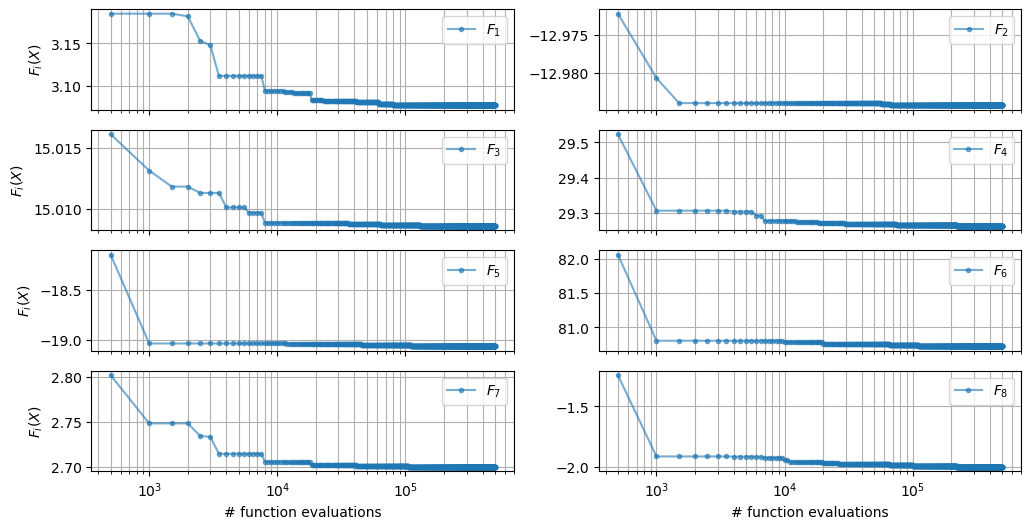

In [24]:
fig, ax = plt.subplots(figsize=(12, 6),nrows=4,ncols=2, sharex=True)
for iobj in range(8):
    nr = int(iobj / 2)
    nc = int(iobj % 2)
    #print(nr,nc)
    ax[nr,nc].plot(n_evals, F_min[:,iobj], '.-',
                    alpha=0.6,
                    label=r'$F_'+str(iobj+1)+'$')
    ax[nr,nc].set_xscale('log')
    if nr == 3:
        ax[nr,nc].set_xlabel('# function evaluations')
    if nc == 0:
        ax[nr,nc].set_ylabel(r'$F_i(X)$')
    ax[nr,nc].grid(which='both')
    ax[nr,nc].legend()
plt.show()

In [25]:
import itertools
import math
from scipy.stats import pearsonr

In [68]:
def tradeoff_index(XX, ncolor=8, out_clr=None, OFnames=None):
    """
    Python translation of MATLAB function tradeoff_index

    Parameters
    ----------
    XX : ndarray (nsols, nobj)
        Objective values
    ncolor : int
        Number of colors
    out_clr : ndarray or None
        Color palette
    OFnames : list of str or None
        Objective names

    Returns
    -------
    hh : matplotlib.figure.Figure
        Figure handle
    lambdas : ndarray
        Lambda matrices (nrows, nrows, ntradeoffs)
    to_names : list
        Trade-off names
    """

    XX = np.asarray(XX, dtype=float)
    nsols, nobj = XX.shape

    # Objective names
    if OFnames is None or len(OFnames) == 0:
        OFnames = [f"obj{i+1}" for i in range(nobj)]

    # Plot options
    #sel_fontname = "Times"
    sel_fontsize = 6
    sel_fontweight = "normal"
    ndecimals = 3
    strformat = f"%.{ndecimals}f"

    # Rescale objectives to [0,1]
    XX2 = (XX - XX.min(axis=0)) / (XX.max(axis=0) - XX.min(axis=0))

    ntradeoffs = math.comb(nobj, 2)
    nrows = int(np.ceil(np.sqrt(nsols)))
    print(nrows)
    
    lambdas = np.zeros((nrows, nrows, ntradeoffs))

    # Correlations
    rhoes = np.zeros((nobj, nobj))
    pvals = np.zeros((nobj, nobj))
    for i in range(nobj):
        for j in range(nobj):
            rhoes[i, j], pvals[i, j] = pearsonr(XX2[:, i], XX2[:, j])

    # ---- Tradeoff Index estimation ----
    to_names = []
    ito = 0

    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            L = np.zeros(nrows * nrows)

            for si in range(nsols):
                beta = np.zeros(nsols)
                for sj in range(nsols):
                    if si != sj:
                        xp = (XX2[si, of1] - XX2[sj, of1]) * \
                             (XX2[si, of2] - XX2[sj, of2])
                        if xp < 0:
                            beta[sj] = 1.0
                L[si] = np.sum(beta) / (nsols - 1)

            lambdas[:, :, ito - 1] = L.reshape((nrows, nrows)).T

            percentage = (np.sum(L) / nsols) * 100
            label = [
                #f"{OFnames[of1]} -> {OFnames[of2]}",
                f"$\\lambda$:{percentage:3.1f}",
                f"$r = {rhoes[of1, of2]:1.3f}$"
            ]
            
            to_names.append(label)

    # ---- Plotting ----
    hh = plt.figure(figsize=(10.1, 9.1), facecolor="white")
    ax = plt.gca()

    xfalse = (np.arange(nrows) + 0.5) / nrows
    text_size = 18 - nobj
    ito = 0
    
    # Colormap
    if out_clr is None:
        out_clr = create_colors(ncolor)

    cmap = plt.colormaps['RdBu_r']#, ncolor)
    
    #plt.clim(0, 1)
    
    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            xp = (of2 - 1) + xfalse
            yp = (nobj - (of1 + 2)) + xfalse
            

            X, Y = np.meshgrid(xp, yp)
            Z = lambdas[:, :, ito - 1]
            ax.pcolormesh(X, Y, Z, shading="nearest", cmap=cmap)

            ax.text(
                np.mean(xp), np.mean(yp),
                "\n".join(to_names[ito - 1]),
                ha = "center", 
                va = "center",
                fontsize   = text_size, #fontname=sel_fontname,
                fontweight = sel_fontweight,
                bbox       = dict(facecolor="white", edgecolor="black")
            )
            #ax.cmap(cmap)
    # Frame
    ax.plot([0, nobj-1, nobj-1, 0, 0],
            [0, 0, nobj-1, nobj-1, 0],
            "k-", linewidth = 0.5)

    plt.grid(which='both')
    #ax.set_xlim(0, nobj - 1)
    #ax.set_ylim(0, nobj - 1)
    ax.set_xticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_yticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_xticklabels(OFnames[1:])#['', ''])
    ax.set_yticklabels(OFnames[::-1][1:])#['', ''])
    ax.set_aspect("equal")

    ax.set_title(
        "Trade-off Index $\\lambda$ [%]", #fontname=sel_fontname,
        fontsize=sel_fontsize + 6,
        fontweight="bold"
    )

    #ax.colorbar()

    #cbar = plt.colorbar(
    #    ticks=np.linspace(0, 1, ncolor + 1),
    #    fraction=0.046, pad=0.04
    #)
    #cbar.ax.set_title("$\\lambda$", fontsize=sel_fontsize + 4)

    return hh, lambdas, to_names

In [69]:
def create_colors(ncolor):
    return plt.cm.RdBu_r(np.linspace(0, 1, ncolor))

In [70]:
F.shape

(500, 8)

23


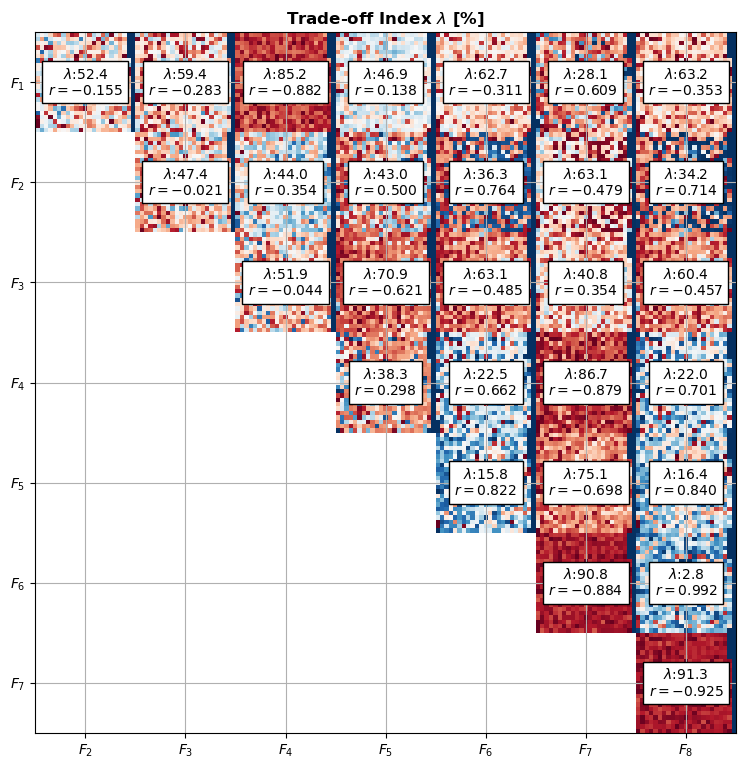

In [71]:
fig, lambdas, names = tradeoff_index(
    F,
    ncolor=8,
    OFnames=['$F_1$', '$F_2$', '$F_3$', '$F_4$','$F_5$','$F_6$','$F_7$','$F_8$'],
)

plt.show()